# Modelling

Initial setup for modelling with randomforest, histgradientboosting and xgboost.

Data output:
* [classifier.joblib](../data_generated/classifier.joblib) Trained model
* [cv_best_by_model.json](../data_generated/cv_best_by_model.json) best parameters


## Todo

- [x] Setup pipeline for testing various models
- [x] Test gradientboosting
- [x] Test logistic regression
- [ ] Add evalutation of model results
- [x] Add new features taredata, flow models, bløtbunnsdatabase ++
- [x] Check waveheight model


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import dump
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

import subkart

## Terrain features

In [2]:
res = subkart.features.RESOLUTION

In [3]:
gdf_sea_map = subkart.sources.sea_map_basisdata(
    #["Oslo", "Ostfold", "Akershus", "Buskerud", "Vestfold", "Rogaland", "Vestland", "More_og_Romsdal", "Trondelag"]
)
crs = gdf_sea_map.crs

Reading preprocessed depth training data for all fylker.


In [4]:
gdf_sea_map = subkart.features.depth_preprocess(gdf_sea_map)
transform, out_shape, bounds = subkart.features.to_raster_shapes(gdf_sea_map, res=res)

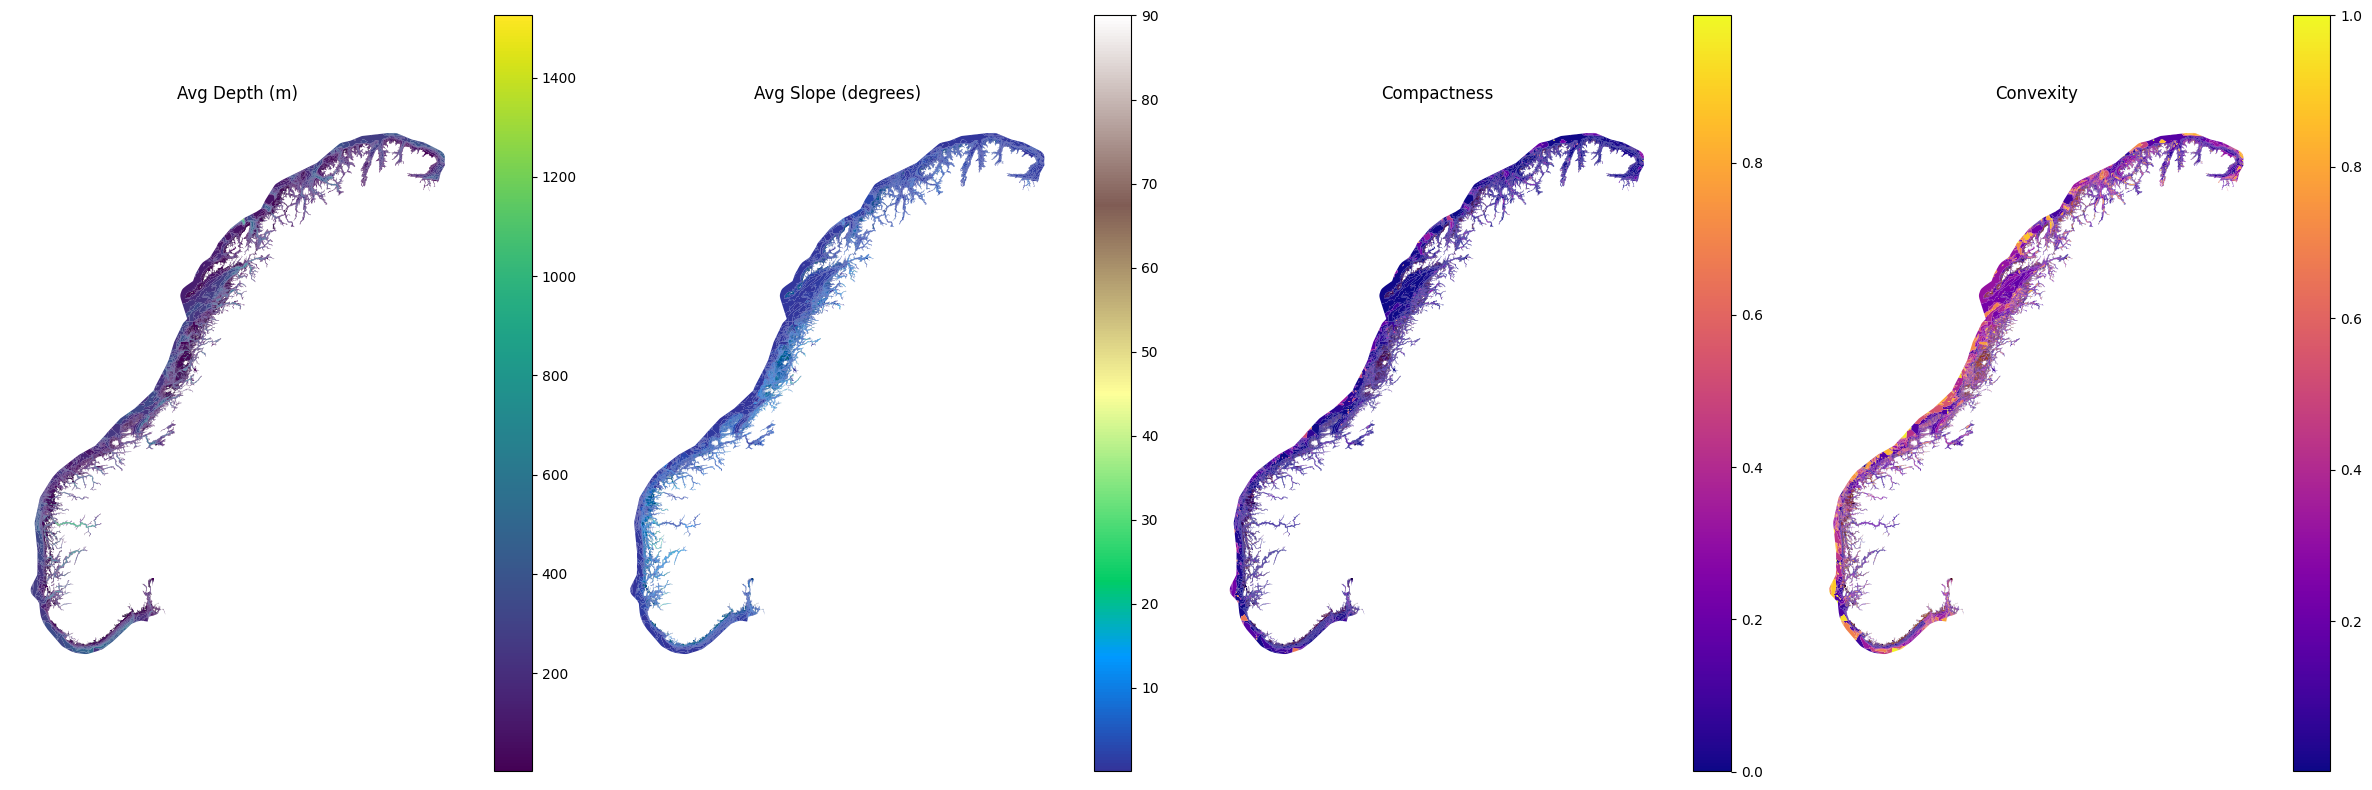

In [5]:
subkart.plot.terrain_features(gdf_sea_map)

## DEM 50

https://kartkatalog.geonorge.no/metadata/dybdedata-terrengmodeller-50-meters-grid/67a3a191-49cc-45bc-baf0-eaaf7c513549

In [6]:
dem = subkart.sources.dem_data()

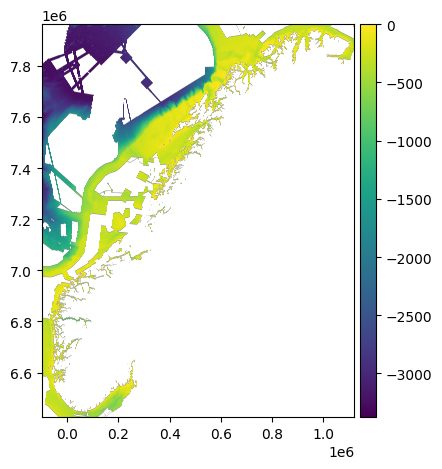

In [7]:
dem = dem.crop(bounds)
dem = subkart.utils.resample_dem(dem, out_shape, transform, crs)
dem.plot()

### Wave exposure features



In [8]:
bolge = subkart.sources.bolge_exposure()


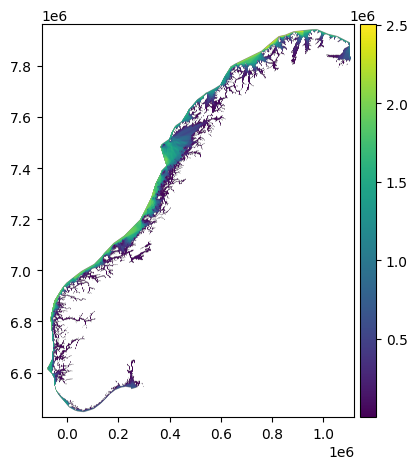

In [9]:
bolge = bolge.reproject(
    crs=crs, res=res,
    bounds=dict(left=bounds[0], bottom=bounds[1], right=bounds[2], top=bounds[3])
)
bolge.plot()

## Dataset for labels

In [10]:
gdf_bunn_full = gpd.read_parquet(
    "gs://niva-geodata/MarintNaturKart/results/nisjedata-substrat-klassifisering_norge_latest_25833.geo.parquet"
)
gdf_bunn_full = gdf_bunn_full.dissolve(by="BunnType", as_index=False)
gdf_bunn_full["BunnType"].unique().tolist()

gdf_bunn_full = gdf_bunn_full.to_crs(crs)
bunn_raster, valid_bunn = subkart.labelling.rasterize_bunn_type(gdf_bunn_full, out_shape=out_shape, transform=transform)
del gdf_bunn_full

## Training

In [11]:
X, valid, out_shape, transform = subkart.features.build(
    dem, gdf_sea_map, bolge, valid_bunn, res=res, dtype=np.float32
)

Preparing sea_avg_depth...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_avg_slope...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_compactness...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_convexity...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing wave exposure...


Stacking feature arrays...


In [12]:
y = bunn_raster[valid]  # labels: {0,1,2}

classes = np.array(list(subkart.labelling.BUNNTYPE_MAPPING.values()), dtype=np.uint8)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = {int(c): float(weight) for c, weight in zip(classes, weights)}
print("Class weights:", class_weights)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Per-sample weights based on class (class 2 fastbunn gets higher weight since it is rare)
sample_weight_train = np.array([class_weights[int(c)] for c in y_train])

### Baseline

Train a quick baseline for each model

In [13]:
baseline_models = [
    XGBClassifier(
        num_class=len(classes),
        n_estimators=300,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=2,
        tree_method="hist",
    ),
    #HistGradientBoostingClassifier(random_state=42, class_weight=class_weights),
    #RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42),
]

score = 0
for base_model in baseline_models:
    m = Pipeline([("model", base_model)])
    m.fit(X_train, y_train, model__sample_weight=sample_weight_train)
    val_score = m.score(X_val, y_val)
    print(f"Baseline {type(base_model).__name__} - " f"Train: {m.score(X_train, y_train):.4f}, Val: {val_score:.4f}")
    if val_score > score:
        score = val_score
        classifier = base_model

Baseline XGBClassifier - Train: 0.7876, Val: 0.7849


## Random Search

Search through hyperparameters for each model, this can take some time

In [14]:
is_random_search = False

if is_random_search:
    classifier = subkart.training.random_search(X_train, y_train, X_val, y_val, classes, class_weights)


In [15]:
is_xgb_random_search = True
if is_xgb_random_search:
    classifier, search_results = subkart.training.optimize_xgboost_hyperparameters(
        X_train, y_train, X_val, y_val, classes, class_weights=class_weights
    )

Starting search around existing parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

Starting randomized search with 50 iterations and 3-fold stratified CV...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


[CV] END colsample_bytree=1.0, gamma=0.48830747791632645, learning_rate=0.18932444159818776, max_depth=9, min_child_weight=1, n_estimators=475, reg_alpha=0.2897897441824462, reg_lambda=2.468358280832689, subsample=0.9942601816442402; total time=38.5min
[CV] END colsample_bytree=1.0, gamma=0.44131817159466985, learning_rate=0.16264485300096554, max_depth=5, min_child_weight=3, n_estimators=496, reg_alpha=1.4519113577404787, reg_lambda=3.691330779857731, subsample=0.954834569706047; total time=21.9min
[CV] END colsample_bytree=1.0, gamma=0.18009532070563145, learning_rate=0.15524726151822618, max_depth=5, min_child_weight=8, n_estimators=402, reg_alpha=0.5430858316394838, reg_lambda=3.8957554911723093, subsample=0.7829060646454915; total time=22.1min


[CV] END colsample_bytree=1.0, gamma=0.2247253370691017, learning_rate=0.15144921397884936, max_depth=10, min_child_weight=8, n_estimators=642, reg_alpha=1.4592123566761281, reg_lambda=2.9126724140656393, subsample=0.9548850970305307; total time=68.2min


[CV] END colsample_bytree=1.0, gamma=0.35342867192380856, learning_rate=0.22748086016491847, max_depth=5, min_child_weight=5, n_estimators=580, reg_alpha=1.302154051003889, reg_lambda=3.7448790266313425, subsample=0.9400154311159197; total time=41.7min
[CV] END colsample_bytree=1.0, gamma=0.44131817159466985, learning_rate=0.16264485300096554, max_depth=5, min_child_weight=3, n_estimators=496, reg_alpha=1.4519113577404787, reg_lambda=3.691330779857731, subsample=0.954834569706047; total time=22.4min
[CV] END colsample_bytree=1.0, gamma=0.18009532070563145, learning_rate=0.15524726151822618, max_depth=5, min_child_weight=8, n_estimators=402, reg_alpha=0.5430858316394838, reg_lambda=3.8957554911723093, subsample=0.7829060646454915; total time=22.3min


[CV] END colsample_bytree=1.0, gamma=0.0002601884976579094, learning_rate=0.1823082627601003, max_depth=7, min_child_weight=7, n_estimators=547, reg_alpha=1.0214946051551315, reg_lambda=2.252233009446337, subsample=0.6888431241882922; total time=50.5min
[CV] END colsample_bytree=1.0, gamma=0.4972752553986705, learning_rate=0.19639334167891317, max_depth=10, min_child_weight=5, n_estimators=355, reg_alpha=0.7403174005108888, reg_lambda=1.0463698495866023, subsample=0.9713274250350902; total time=28.0min


...

[CV] END colsample_bytree=1.0, gamma=0.46484882617128653, learning_rate=0.23697444554773006, max_depth=5, min_child_weight=5, n_estimators=483, reg_alpha=0.9130691409658205, reg_lambda=1.6553213116505008, subsample=0.7666039791481465; total time=34.8min
[CV] END colsample_bytree=1.0, gamma=0.4917115704474215, learning_rate=0.1878589330933464, max_depth=5, min_child_weight=9, n_estimators=473, reg_alpha=1.0163975534814373, reg_lambda=3.0874384203726457, subsample=0.943343521925488; total time=24.0min
[CV] END colsample_bytree=1.0, gamma=0.27640998845395387, learning_rate=0.17558121723773584, max_depth=6, min_child_weight=3, n_estimators=362, reg_alpha=0.16318836080048071, reg_lambda=1.0155545883219603, subsample=0.8511577659794545; total time=23.7min
[CV] END colsample_bytree=1.0, gamma=0.325742385928894, learning_rate=0.16480212318520945, max_depth=9, min_child_weight=2, n_estimators=602, reg_alpha=0.1888859215118568, reg_lambda=3.0490203202490704, subsample=0.6284754593840917; total t

[CV] END colsample_bytree=1.0, gamma=0.06974693032602092, learning_rate=0.17505735782422618, max_depth=10, min_child_weight=3, n_estimators=404, reg_alpha=1.9664617716135764, reg_lambda=2.40028867974394, subsample=0.9439761626945282; total time=55.0min
[CV] END colsample_bytree=1.0, gamma=0.33009868835886563, learning_rate=0.17359206763351315, max_depth=9, min_child_weight=7, n_estimators=541, reg_alpha=1.1087081050228014, reg_lambda=2.835162238703057, subsample=0.767840024971116; total time=45.2min


[CV] END colsample_bytree=1.0, gamma=0.48830747791632645, learning_rate=0.18932444159818776, max_depth=9, min_child_weight=1, n_estimators=475, reg_alpha=0.2897897441824462, reg_lambda=2.468358280832689, subsample=0.9942601816442402; total time=39.1min
[CV] END colsample_bytree=1.0, gamma=0.44131817159466985, learning_rate=0.16264485300096554, max_depth=5, min_child_weight=3, n_estimators=496, reg_alpha=1.4519113577404787, reg_lambda=3.691330779857731, subsample=0.954834569706047; total time=22.1min
[CV] END colsample_bytree=1.0, gamma=0.4210115375059907, learning_rate=0.1633256040793848, max_depth=10, min_child_weight=3, n_estimators=493, reg_alpha=1.9517041589250692, reg_lambda=2.548901044903586, subsample=0.7291825891764985; total time=46.3min


[CV] END colsample_bytree=1.0, gamma=0.34775804321306375, learning_rate=0.15671977452870509, max_depth=9, min_child_weight=4, n_estimators=362, reg_alpha=0.15395981965758598, reg_lambda=1.869254358741304, subsample=0.6644885149016019; total time=46.8min
[CV] END colsample_bytree=1.0, gamma=0.4972752553986705, learning_rate=0.19639334167891317, max_depth=10, min_child_weight=5, n_estimators=355, reg_alpha=0.7403174005108888, reg_lambda=1.0463698495866023, subsample=0.9713274250350902; total time=26.0min
[CV] END colsample_bytree=1.0, gamma=0.325742385928894, learning_rate=0.16480212318520945, max_depth=9, min_child_weight=2, n_estimators=602, reg_alpha=0.1888859215118568, reg_lambda=3.0490203202490704, subsample=0.6284754593840917; total time=31.0min



Optimization complete!
Best CV score: 0.8186
CV train score: 0.8518
Train accuracy: 0.8457
Validation accuracy: 0.8219
Overfitting gap (train - val): 0.0237

Best parameters:
  colsample_bytree: 1.0
  gamma: 0.25440703841938
  learning_rate: 0.21635991418230746
  max_depth: 10
  min_child_weight: 6
  n_estimators: 579
  reg_alpha: 0.7861954493335208
  reg_lambda: 3.67613966553134
  subsample: 0.8524554503989052


In [16]:
dump(classifier, subkart.utils.model_dir_path() / "classifier.joblib")

['/home/jovyan/marint-naturkart-niva/model/classifier.joblib']

dem_depth: mean=0.153258, std=0.000290
wave_exposure: mean=0.123907, std=0.000260
dem_slope: mean=0.096355, std=0.000262
sea_convexity: mean=0.091900, std=0.000231
sea_avg_slope: mean=0.079509, std=0.000198
sea_compactness: mean=0.071432, std=0.000246
dem_curvature: mean=0.070001, std=0.000266
sea_avg_depth: mean=0.061637, std=0.000274
is_dem: mean=0.002685, std=0.000058


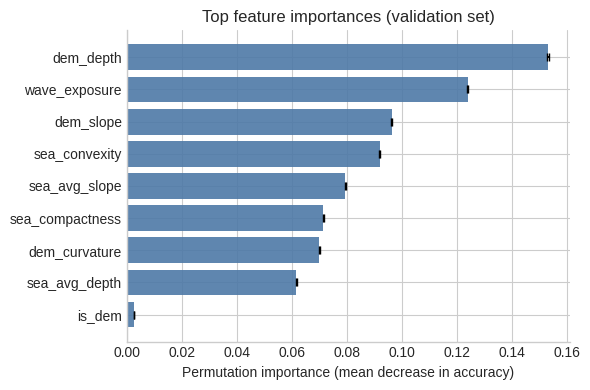

In [17]:
subkart.plot.feature_importance(classifier, X_val, y_val)

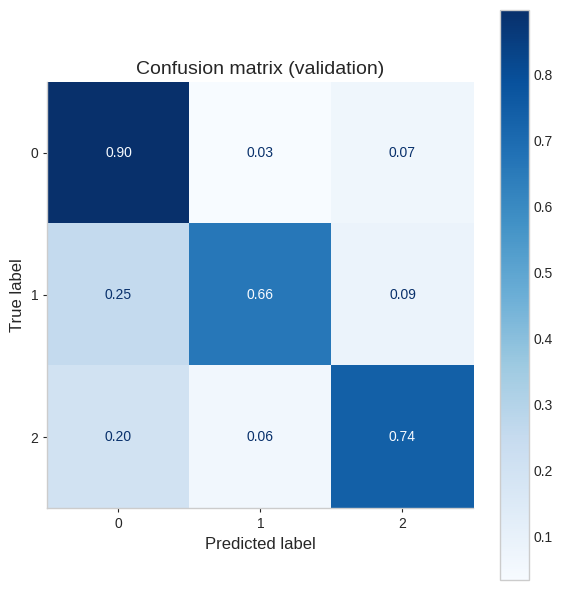

In [18]:
# Predict on validation set
y_val_pred = classifier.predict(X_val)

# Compute confusion matrix (normalized by true class)
cm = confusion_matrix(y_val, y_val_pred, labels=classes, normalize="true")

subkart.plot.confusion_matrix(cm, classes)

In [19]:
# Print classification report
print("Classification report (validation):")
report_dict = classification_report(
    y_val,
    y_val_pred,
    labels=classes,
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).T
report_df


Classification report (validation):


,precision,recall,f1-score,support
0,0.860503,0.897071,0.878406,6.930580e+05
1,0.739875,0.659684,0.697482,1.761860e+05
2,0.765988,0.737426,0.751435,2.777350e+05
accuracy,0.821949,0.821949,0.821949,8.219488e-01
macro avg,0.788789,0.764727,0.775775,1.146979e+06
weighted avg,0.819087,0.821949,0.819869,1.146979e+06
